#  Data & AI Job Market Analysis
## Notebook 1 — Exploratory Data Analysis

**Author:** Francisco Martinez Grecco  
**Dataset:** Data Science Job Salaries (Kaggle)  
**Objective:** Uncover salary trends, remote work patterns, and market dynamics across the global Data & AI job market.

---

## Section 1 — Setup & Data Loading

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sys
sys.path.append('..')

# Custom project modules
from src.clean import load_raw_data, clean_salaries_df
from src.features import build_features

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Global plot style: clean white grid + viridis palette
sns.set_theme(style='whitegrid', palette='viridis')

In [2]:

# Load raw CSV from data/raw/
df_raw = load_raw_data('../data/raw/ds_salaries.csv')

# Apply cleaning pipeline
df = clean_salaries_df(df_raw)

# Apply feature engineering: add remote_category, experience_rank,
# and company_size_rank columns for later analysis
df = build_features(df)

Loaded 607 rows × 12 columns
Removed 42 duplicate rows
Cleaned dataset: 565 rows × 11 columns
Features added. New shape: 565 rows × 14 columns


In [3]:
# Verify that data loaded correctly
df.head(10)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,remote_category,experience_rank,company_size_rank
0,2020,Mid-Level,Full-Time,Data Scientist,70000,EUR,79833,DE,0,DE,Large,On-site,1,2
1,2020,Senior,Full-Time,Machine Learning Scientist,260000,USD,260000,JP,0,JP,Small,On-site,2,0
2,2020,Senior,Full-Time,Big Data Engineer,85000,GBP,109024,GB,50,GB,Medium,Hybrid,2,1
3,2020,Mid-Level,Full-Time,Product Data Analyst,20000,USD,20000,HN,0,HN,Small,On-site,1,0
4,2020,Senior,Full-Time,Machine Learning Engineer,150000,USD,150000,US,50,US,Large,Hybrid,2,2
5,2020,Entry-Level,Full-Time,Data Analyst,72000,USD,72000,US,100,US,Large,Remote,0,2
6,2020,Senior,Full-Time,Lead Data Scientist,190000,USD,190000,US,100,US,Small,Remote,2,0
7,2020,Mid-Level,Full-Time,Data Scientist,11000000,HUF,35735,HU,50,HU,Large,Hybrid,1,2
8,2020,Mid-Level,Full-Time,Business Data Analyst,135000,USD,135000,US,100,US,Large,Remote,1,2
9,2020,Senior,Full-Time,Lead Data Engineer,125000,USD,125000,NZ,50,NZ,Small,Hybrid,2,0


In [4]:
# Dataset shape and column types
df.info()

<class 'pandas.DataFrame'>
Index: 565 entries, 0 to 606
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           565 non-null    int64
 1   experience_level    565 non-null    str  
 2   employment_type     565 non-null    str  
 3   job_title           565 non-null    str  
 4   salary              565 non-null    int64
 5   salary_currency     565 non-null    str  
 6   salary_in_usd       565 non-null    int64
 7   employee_residence  565 non-null    str  
 8   remote_ratio        565 non-null    int64
 9   company_location    565 non-null    str  
 10  company_size        565 non-null    str  
 11  remote_category     565 non-null    str  
 12  experience_rank     565 non-null    int64
 13  company_size_rank   565 non-null    int64
dtypes: int64(6), str(8)
memory usage: 66.2 KB


In [5]:
# Summary statistics for numeric columns
# Key things to notice: mean vs median salary,
# min/max range, and standard deviation
df.describe()

,work_year,salary,salary_in_usd,remote_ratio,experience_rank,company_size_rank
count,565.00,565.00,565.00,565.00,565.00,565.00
mean,"2,021.36","338,115.99","110,610.34",69.91,1.37,1.20
std,0.70,"1,599,878.79","72,280.70",40.90,0.80,0.67
min,"2,020.00","4,000.00","2,859.00",0.00,0.00,0.00
25%,"2,021.00","67,000.00","60,757.00",50.00,1.00,1.00
50%,"2,021.00","110,925.00","100,000.00",100.00,1.00,1.00
75%,"2,022.00","165,000.00","150,000.00",100.00,2.00,2.00
max,"2,022.00","30,400,000.00","600,000.00",100.00,3.00,2.00


In [6]:
# Check for missing values 
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
remote_category       0
experience_rank       0
company_size_rank     0
dtype: int64

Total missing: 0


In [7]:
# Top 10 most common job titles
# This reveals the market composition: which roles dominate the dataset
print("Top 10 Job Titles:")
print(df['job_title'].value_counts().head(10))

Top 10 Job Titles:
job_title
Data Scientist                130
Data Engineer                 121
Data Analyst                   82
Machine Learning Engineer      39
Research Scientist             16
Data Science Manager           12
Data Architect                 11
Machine Learning Scientist      8
Big Data Engineer               8
Data Science Consultant         7
Name: count, dtype: int64


---
## Section 2 — Univariate Analysis: Salary Distribution

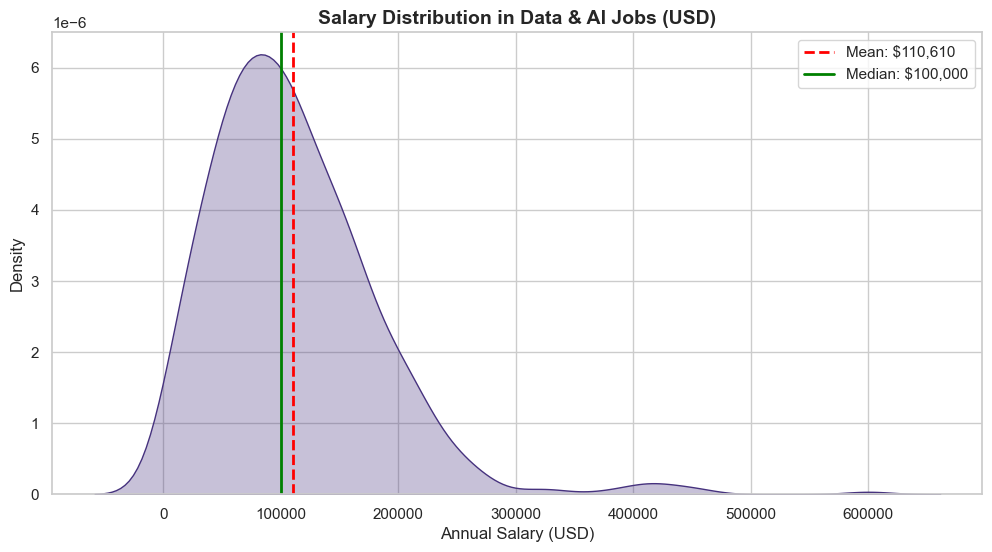


Skewness: 1.73
Kurtosis: 6.45


In [8]:

# SALARY DISTRIBUTION — KDE CURVE
# A Kernel Density Estimate shows the shape of the salary
# distribution. The mean vs median gap reveals skewness:
# if mean > median, the distribution is right-skewed (pulled by
# high earners). This is one of the first things an employer
# looks for in an EDA

import os
os.makedirs('../outputs/figures', exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 6))

# Density curve
sns.kdeplot(data=df, x='salary_in_usd', fill=True, alpha=0.3, ax=ax)

# Calculate and plot mean and median
mean_sal = df['salary_in_usd'].mean()
median_sal = df['salary_in_usd'].median()

ax.axvline(mean_sal, color='red', linestyle='--', linewidth=2,
           label=f'Mean: ${mean_sal:,.0f}')
ax.axvline(median_sal, color='green', linestyle='-', linewidth=2,
           label=f'Median: ${median_sal:,.0f}')

ax.set_title('Salary Distribution in Data & AI Jobs (USD)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Annual Salary (USD)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=11)

plt.savefig('../outputs/figures/salary_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSkewness: {df['salary_in_usd'].skew():.2f}")
print(f"Kurtosis: {df['salary_in_usd'].kurtosis():.2f}")

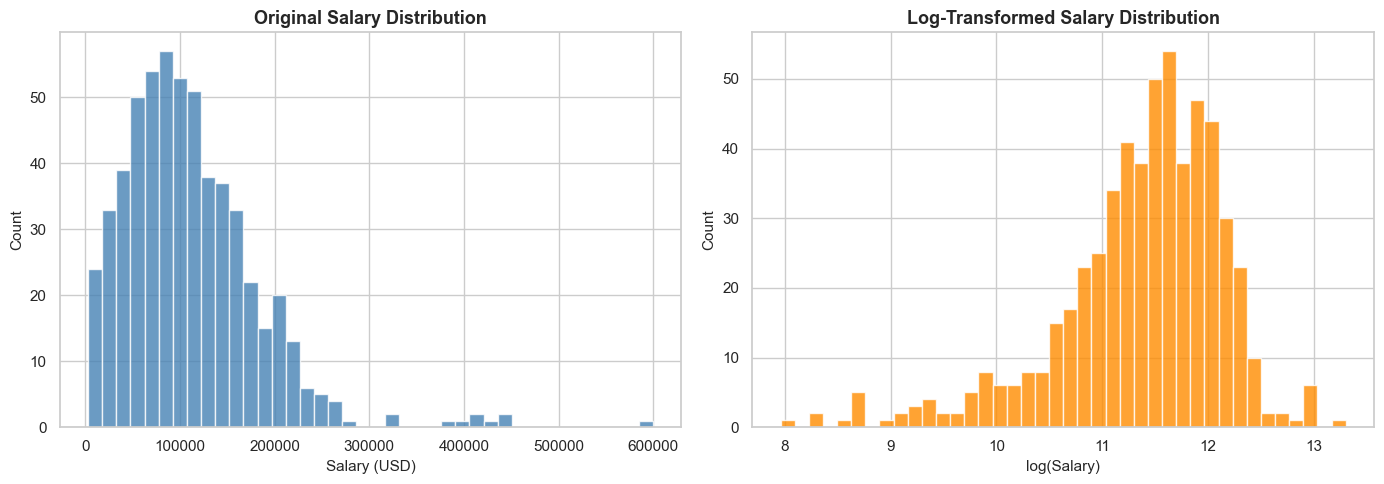

Original skewness:      1.73
Log-transformed skew:   -1.20


In [9]:

# Log-transformed salary distribution
# When a distribution is right-skewed, applying log() compresses
# the long tail and makes the data more symmetric.
# This is important because ML models often perform better on log-transformed targets.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution
axes[0].hist(df['salary_in_usd'], bins=40, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[0].set_title('Original Salary Distribution',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Salary (USD)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)

# Log-transformed distribution
df['log_salary'] = np.log1p(df['salary_in_usd'])
axes[1].hist(df['log_salary'], bins=40, color='darkorange',
             edgecolor='white', alpha=0.8)
axes[1].set_title('Log-Transformed Salary Distribution',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Salary)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/figures/salary_log_transform.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Original skewness:      {df['salary_in_usd'].skew():.2f}")
print(f"Log-transformed skew:   {df['log_salary'].skew():.2f}")

---
## Section 3 — Univariate Analysis: Categorical Variables


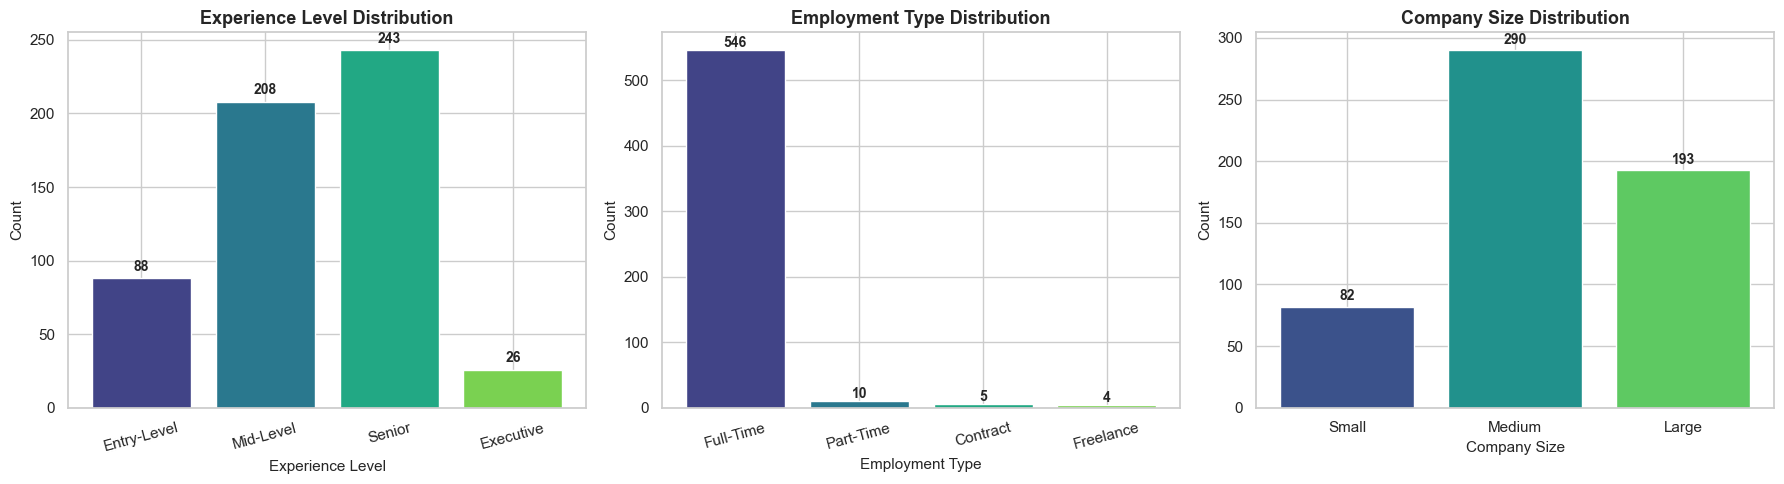

In [10]:

# Distribution of experience levels, employment types, company sizes
# Understanding the composition of the dataset is critical
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Experience Level: Are most jobs senior or junior? 
exp_order = ['Entry-Level', 'Mid-Level', 'Senior', 'Executive']
exp_counts = df['experience_level'].value_counts().reindex(exp_order)
axes[0].bar(exp_counts.index, exp_counts.values,
            color=sns.color_palette('viridis', 4), edgecolor='white')
axes[0].set_title('Experience Level Distribution',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Experience Level', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

for i, (val, count) in enumerate(zip(exp_counts.index, exp_counts.values)):
    axes[0].text(i, count + 5, str(count), ha='center',
                fontweight='bold', fontsize=10)

# Employment Type: It is common to work in a part-time job? 
emp_counts = df['employment_type'].value_counts()
axes[1].bar(emp_counts.index, emp_counts.values,
            color=sns.color_palette('viridis', len(emp_counts)),
            edgecolor='white')
axes[1].set_title('Employment Type Distribution',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Employment Type', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)
for i, (val, count) in enumerate(zip(emp_counts.index, emp_counts.values)):
    axes[1].text(i, count + 5, str(count), ha='center',
                fontweight='bold', fontsize=10)

# Company Size: Are most jobs at small, medium, or large companies?
size_order = ['Small', 'Medium', 'Large']
size_counts = df['company_size'].value_counts().reindex(size_order)
axes[2].bar(size_counts.index, size_counts.values,
            color=sns.color_palette('viridis', 3), edgecolor='white')
axes[2].set_title('Company Size Distribution',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Company Size', fontsize=11)
axes[2].set_ylabel('Count', fontsize=11)
for i, (val, count) in enumerate(zip(size_counts.index, size_counts.values)):
    axes[2].text(i, count + 5, str(count), ha='center',
                fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/categorical_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 — Bivariate Analysis: Salary vs Experience & Company Size

C:\Users\frann\AppData\Local\Temp\ipykernel_14516\3224935231.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='experience_level', y='salary_in_usd',


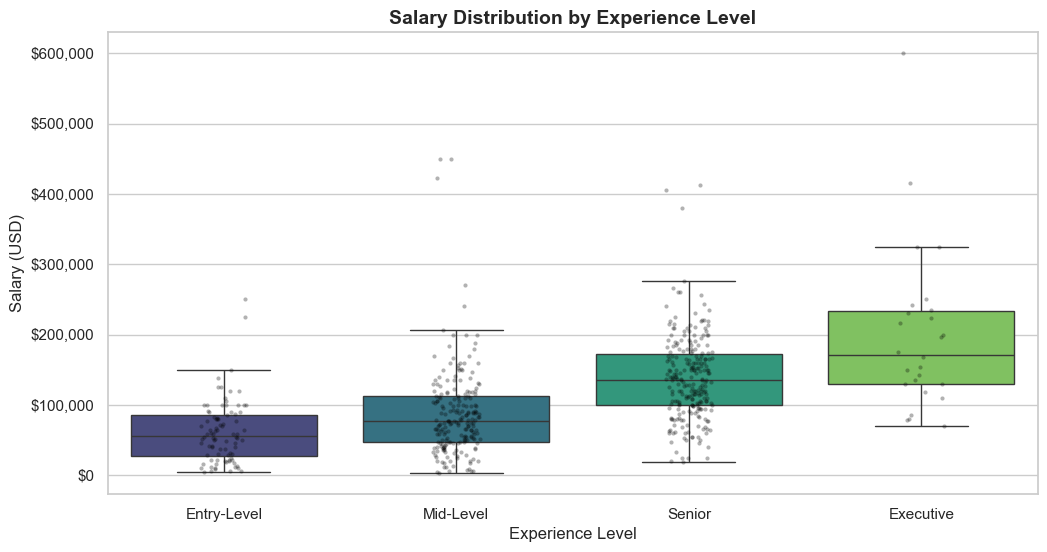


Median salary by experience level:
experience_level
Entry-Level     $56,500
Mid-Level       $76,940
Senior         $135,000
Executive      $171,438
Name: salary_in_usd, dtype: str


In [11]:

# Salary vs Experience Level
# - Boxplots show median, IQR, and outliers per group
# - Stripplot overlays individual data points for transparency
# - Together they reveal both the distribution shape and sample size
fig, ax = plt.subplots(figsize=(12, 6))

exp_order = ['Entry-Level', 'Mid-Level', 'Senior', 'Executive']

# Boxplot: shows median, quartiles, and outlier fences
sns.boxplot(data=df, x='experience_level', y='salary_in_usd',
            order=exp_order, palette='viridis', ax=ax,
            fliersize=0) 
# Stripplot: overlay actual data points with jitter
sns.stripplot(data=df, x='experience_level', y='salary_in_usd',
              order=exp_order, color='black', alpha=0.3,
              size=3, jitter=True, ax=ax)

ax.set_title('Salary Distribution by Experience Level',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Experience Level', fontsize=12)
ax.set_ylabel('Salary (USD)', fontsize=12)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.savefig('../outputs/figures/salary_vs_experience.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print median salaries per group for reference
print("\nMedian salary by experience level:")
print(df.groupby('experience_level')['salary_in_usd']
      .median().reindex(exp_order)
      .apply(lambda x: f'${x:,.0f}'))

C:\Users\frann\AppData\Local\Temp\ipykernel_14516\2565219815.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='company_size', y='salary_in_usd',


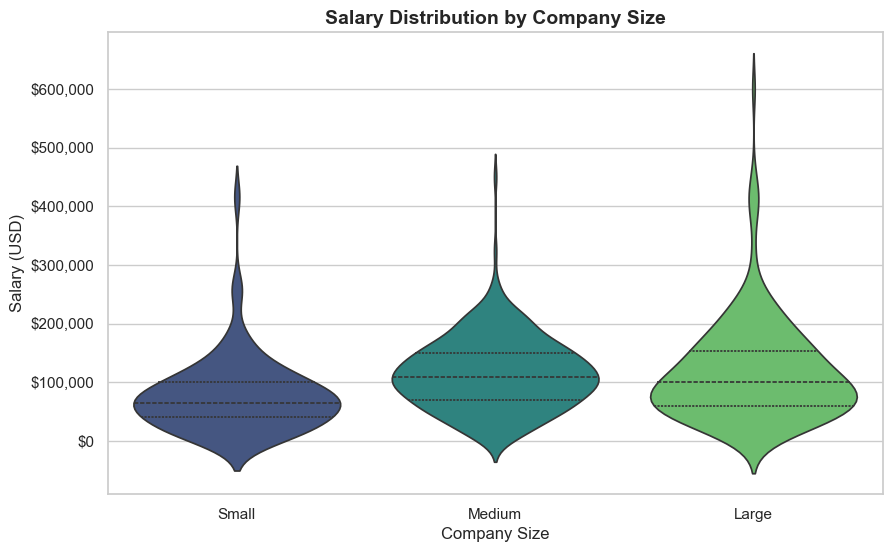


Median salary by company size:
company_size
Small      $65,511
Medium    $109,640
Large     $100,000
Name: salary_in_usd, dtype: str


In [12]:

# Salary vs Company Size 
# Violin plots combine a boxplot with a KDE on each side.
# This reveals the full shape of the distribution per group, not just the quartiles
# This is a more advanced visualization than a simple boxplot.
fig, ax = plt.subplots(figsize=(10, 6))

size_order = ['Small', 'Medium', 'Large']

sns.violinplot(data=df, x='company_size', y='salary_in_usd',
               order=size_order, palette='viridis',
               inner='quartile', ax=ax)  # inner='quartile' shows IQR lines

ax.set_title('Salary Distribution by Company Size',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Company Size', fontsize=12)
ax.set_ylabel('Salary (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.savefig('../outputs/figures/salary_vs_company_size.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print median salaries per group
print("\nMedian salary by company size:")
print(df.groupby('company_size')['salary_in_usd']
      .median().reindex(size_order)
      .apply(lambda x: f'${x:,.0f}'))

---
## Section 5 — Bivariate Analysis: Remote Work & Time Trends

C:\Users\frann\AppData\Local\Temp\ipykernel_14516\2272160685.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='remote_category', y='salary_in_usd',


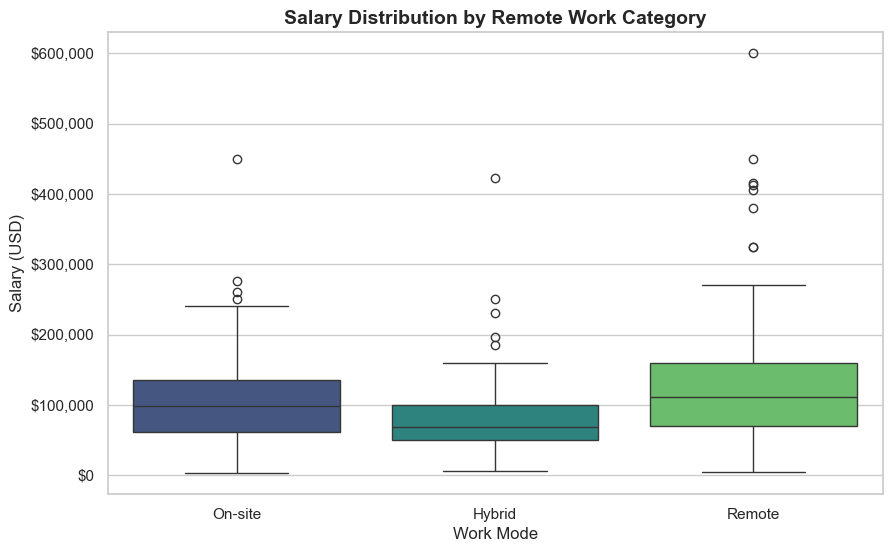


Jobs and median salary by work mode:
                 count median_salary
remote_category                     
On-site            121       $98,158
Hybrid              98       $68,010
Remote             346      $110,712


In [13]:
# This chart answers: Do remote workers earn more or less?
# We treat remote_ratio as categorical (On-site / Hybrid / Remote)
# using the remote_category column created by build_features().
fig, ax = plt.subplots(figsize=(10, 6))

remote_order = ['On-site', 'Hybrid', 'Remote']

sns.boxplot(data=df, x='remote_category', y='salary_in_usd',
            order=remote_order, palette='viridis', ax=ax)

ax.set_title('Salary Distribution by Remote Work Category',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Work Mode', fontsize=12)
ax.set_ylabel('Salary (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.savefig('../outputs/figures/salary_vs_remote.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print counts and medians per remote category
print("\nJobs and median salary by work mode:")
remote_summary = df.groupby('remote_category').agg(
    count=('salary_in_usd', 'count'),
    median_salary=('salary_in_usd', 'median')
).reindex(remote_order)
remote_summary['median_salary'] = remote_summary['median_salary'].apply(
    lambda x: f'${x:,.0f}')
print(remote_summary)

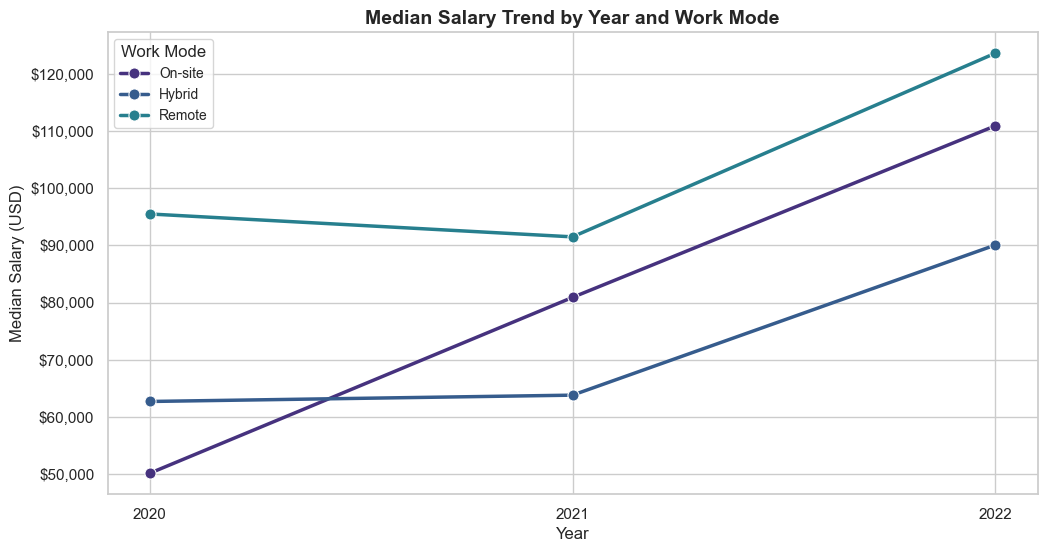


Overall median salary by year:
  2020: $75,544
  2021: $82,528
  2022: $120,000


In [14]:

# This lineplot shows how salaries have evolved from 2020 to 2022.
# We break it down by remote category to see if the trend
# differs for on-site vs remote workers.
fig, ax = plt.subplots(figsize=(12, 6))

# Calculate median salary per year and remote category
trend = (df.groupby(['work_year', 'remote_category'])['salary_in_usd']
         .median()
         .reset_index())

sns.lineplot(data=trend, x='work_year', y='salary_in_usd',
             hue='remote_category', hue_order=remote_order,
             marker='o', linewidth=2.5, markersize=8, ax=ax)

ax.set_title('Median Salary Trend by Year and Work Mode',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Median Salary (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax.set_xticks(sorted(df['work_year'].unique()))

ax.legend(title='Work Mode', fontsize=10)

plt.savefig('../outputs/figures/salary_trend_by_year.png',
            dpi=150, bbox_inches='tight')
plt.show()

yearly_median = df.groupby('work_year')['salary_in_usd'].median()
print("\nOverall median salary by year:")
for year, sal in yearly_median.items():
    print(f"  {year}: ${sal:,.0f}")